# Project 2 — Predicting Business AI Use with Census BTOS Data

**Machine-learning task:** Multi-output regression.

The model predicts the percentage of businesses in each **sector × employment-size group** that report **Yes**, **No**, or **Do not know** to the current AI-use question in the most recent available BTOS survey period.

The public BTOS files contain **aggregated survey estimates**, not business-level microdata. Census-suppressed estimates are treated as unavailable values rather than zeros. Groups without all three published target percentages are excluded from model training; missing predictor estimates are imputed **inside the modeling pipeline** so preprocessing is learned only from training folds during cross-validation.

## 1. Imports and configuration

This notebook is intentionally self-contained. Put `Sector by Employment Size Class.xlsx` in the same folder as the notebook before running **Restart Kernel → Run All**.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
N_SPLITS = 5

DATA_FILE = Path("Sector by Employment Size Class.xlsx")

if not DATA_FILE.exists():
    matches = list(Path("C:/Users/McCaiT01/OneDrive - CPGPLC/Misc/Code/DTSC Studio 2").glob("*Sector*Employment*Size*.xlsx"))
    if matches:
        DATA_FILE = matches[0]
    else:
        raise FileNotFoundError(
            "Could not find 'Sector by Employment Size Class.xlsx'. "
            "Place the Excel file in the same folder as this notebook and run again."
        )

print(f"Using data file: {DATA_FILE.resolve()}")

Using data file: C:\Users\McCaiT01\OneDrive - CPGPLC\Misc\Code\DTSC Studio 2\Sector by Employment Size Class.xlsx


## 2. Load the BTOS response estimates

In [3]:
df = pd.read_excel(DATA_FILE, sheet_name="Response Estimates")

print("Raw data shape:", df.shape)
print("Unique questions:", df["Question"].nunique())
print("Unique sector × employment-size groups:",
      df[["Sector", "Empsize"]].drop_duplicates().shape[0])

time_columns = [
    col for col in df.columns
    if str(col).isdigit() and len(str(col)) == 6
]

current_period = max(time_columns, key=lambda x: int(str(x)))
print("Most recent available survey period:", current_period)

Raw data shape: (11622, 85)
Unique questions: 22
Unique sector × employment-size groups: 142
Most recent available survey period: 202619


## 3. Define the target and predictor questions

The target is the current AI-use question. Because the public table reports percentages for three response categories, the model predicts three continuous outcomes that together total approximately 100%.

In [4]:
target_question = (
    "In the last two weeks, did this business use Artificial Intelligence "
    "(AI) in any of its business functions? (Examples of AI: machine learning, "
    "natural language processing, virtual agents, voice recognition, etc.)"
)

predictor_questions = [
    "Overall, how would you describe this business's current performance?",
    "In the last two weeks, how did this business's operating revenues/sales/receipts change?",
    "In the last two weeks, how did this business's number of paid employees change?",
    "In the last two weeks, how did the total number of hours worked by this business's paid employees change?",
    "In the last two weeks, how did the time it takes for this business to receive deliveries from suppliers change?",
    "How would you describe this business's current inventories?",
    "In the last two weeks, how did demand for this business's goods or services change?",
    "In the last two weeks, how did the prices this business charges for its own goods or services change?",
    "In the last two weeks, how did the prices this business pays for goods or services change?",
    "In the last six months, in what ways did changes to interest rates negatively impact this business?",
    "In the last six months, did this business experience any monetary losses due to an extreme weather event (for example, hurricane, flood, drought, or heat wave)?",
]

print("Predictor questions selected:", len(predictor_questions))

Predictor questions selected: 11


## 4. Clean and reshape the target

Suppressed or otherwise unavailable estimates are converted to `NaN`. They are **not** interpreted as 0%. Only sector × employment-size groups with all three target percentages published are retained for supervised learning.

In [5]:
SUPPRESSED_VALUES = {"S", "NA", "N/A", "-", "", "nan", "None"}

def to_numeric_estimate(series):
    cleaned = (
        series.astype(str)
        .str.strip()
        .str.replace("%", "", regex=False)
        .replace(list(SUPPRESSED_VALUES), np.nan)
    )
    return pd.to_numeric(cleaned, errors="coerce")

# Extract target rows for the selected period
target_long = df.loc[
    df["Question"].eq(target_question),
    ["Sector", "Empsize", "Answer", current_period]
].copy()

target_long = target_long.rename(
    columns={"Answer": "AI_Use", current_period: "Target_Value"}
)

target_long["Target_Percent"] = to_numeric_estimate(target_long["Target_Value"])

# Reshape Yes / No / Do not know into separate target columns
target_wide = (
    target_long
    .pivot_table(
        index=["Sector", "Empsize"],
        columns="AI_Use",
        values="Target_Percent",
        aggfunc="first"
    )
    .reset_index()
)
target_wide.columns.name = None

target_wide = target_wide.rename(columns={
    "Yes": "Target_Yes",
    "No": "Target_No",
    "Do not know": "Target_Do_not_know"
})

target_cols = ["Target_Yes", "Target_No", "Target_Do_not_know"]

target_wide["Published_Targets"] = target_wide[target_cols].notna().sum(axis=1)

print("Target availability by group:")
display(target_wide["Published_Targets"].value_counts().sort_index())

complete_target = target_wide.dropna(subset=target_cols).copy()
complete_target["Target_Total"] = complete_target[target_cols].sum(axis=1)

print("Complete target groups:", len(complete_target))
print("Target total range:",
      round(complete_target["Target_Total"].min(), 2), "to",
      round(complete_target["Target_Total"].max(), 2))

Target availability by group:


Published_Targets
1    19
2    16
3    89
Name: count, dtype: int64

Complete target groups: 89
Target total range: 99.9 to 100.1


## 5. Clean and reshape predictor estimates

Each question-answer percentage becomes a numeric feature. Suppressed predictor estimates remain missing here and are imputed later **inside each training fold**.

In [6]:
predictor_long = df.loc[
    df["Question"].isin(predictor_questions),
    ["Sector", "Empsize", "Question", "Answer", current_period]
].copy()

predictor_long = predictor_long.rename(columns={current_period: "Value"})
predictor_long["Value"] = to_numeric_estimate(predictor_long["Value"])

# Pivot to one row per sector × employment-size group
feature_df = (
    predictor_long
    .pivot_table(
        index=["Sector", "Empsize"],
        columns=["Question", "Answer"],
        values="Value",
        aggfunc="first"
    )
    .reset_index()
)

# Flatten the MultiIndex columns into readable strings
flat_columns = []
for col in feature_df.columns:
    if isinstance(col, tuple):
        parts = [str(x) for x in col if str(x) not in ("", "nan", "None")]
        flat_columns.append("_".join(parts))
    else:
        flat_columns.append(str(col))
feature_df.columns = flat_columns

print("Feature groups:", len(feature_df))
print("Feature matrix shape including keys:", feature_df.shape)

Feature groups: 128
Feature matrix shape including keys: (128, 40)


## 6. Build the final modeling dataset

The merge is restricted to groups with complete published target estimates. Predictor suppression is retained for pipeline imputation.

In [7]:
modeling_df = feature_df.merge(
    complete_target[["Sector", "Empsize"] + target_cols + ["Target_Total"]],
    on=["Sector", "Empsize"],
    how="inner",
    validate="one_to_one"
)

print("Final modeling shape:", modeling_df.shape)
print("Observational units:", len(modeling_df))
print("Duplicate groups:", modeling_df[["Sector", "Empsize"]].duplicated().sum())

predictor_numeric_cols = [
    c for c in modeling_df.columns
    if c not in ["Sector", "Empsize"] + target_cols + ["Target_Total"]
]

print("Numeric survey predictors:", len(predictor_numeric_cols))
print("Total predictors including Sector and Empsize:", len(predictor_numeric_cols) + 2)
print("Missing predictor estimates:", int(modeling_df[predictor_numeric_cols].isna().sum().sum()))

print()
print("Target summary:")
display(modeling_df[target_cols].describe().round(2))

Final modeling shape: (89, 44)
Observational units: 89
Duplicate groups: 0
Numeric survey predictors: 38
Total predictors including Sector and Empsize: 40
Missing predictor estimates: 501

Target summary:


,Target_Yes,Target_No,Target_Do_not_know
count,89.00,89.00,89.00
mean,29.14,57.36,13.50
std,13.30,16.44,5.92
min,5.90,12.00,5.70
25%,18.70,46.30,9.70
50%,26.50,60.70,11.50
75%,36.90,70.00,16.60
max,61.90,84.90,34.50


## 7. Exploratory data analysis

These plots are placed **before model training** because they describe the outcome distribution and show how reported AI use varies across employment-size and sector groups. The figures are also saved as PNG files for use on the portfolio page.

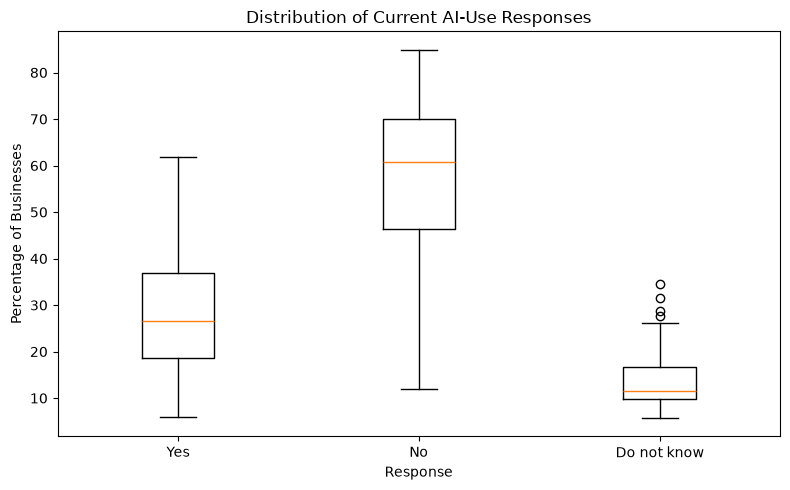

In [8]:
# Plot 1 — Target distribution
plot_df = modeling_df[target_cols].rename(columns={
    "Target_Yes": "Yes",
    "Target_No": "No",
    "Target_Do_not_know": "Do not know"
})

plt.figure(figsize=(8, 5))
plt.boxplot(
    [plot_df[c].dropna() for c in plot_df.columns],
    tick_labels=plot_df.columns
)
plt.title("Distribution of Current AI-Use Responses")
plt.xlabel("Response")
plt.ylabel("Percentage of Businesses")
plt.tight_layout()
plt.savefig("eda_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

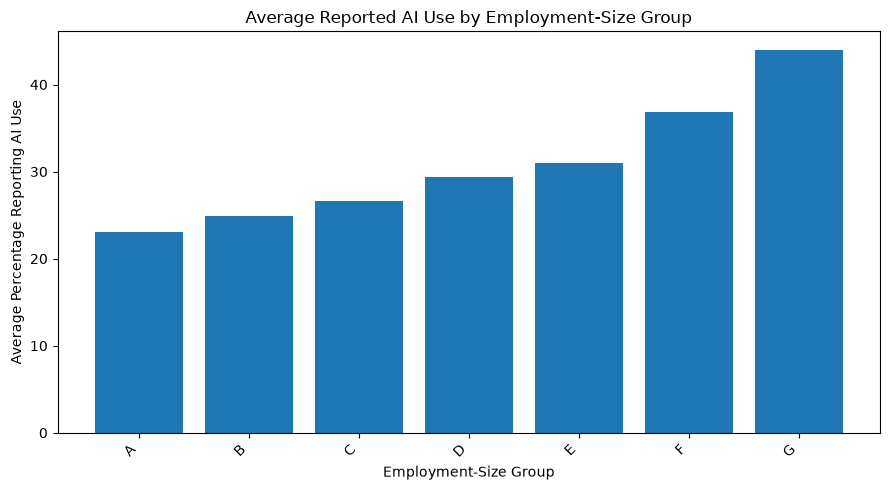

In [9]:
# Plot 2 — Average AI use by employment-size group
ai_by_size = (
    modeling_df
    .groupby("Empsize", dropna=False)["Target_Yes"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(9, 5))
plt.bar(ai_by_size.index.astype(str), ai_by_size.values)
plt.title("Average Reported AI Use by Employment-Size Group")
plt.xlabel("Employment-Size Group")
plt.ylabel("Average Percentage Reporting AI Use")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("eda_ai_use_by_employment_size.png", dpi=300, bbox_inches="tight")
plt.show()

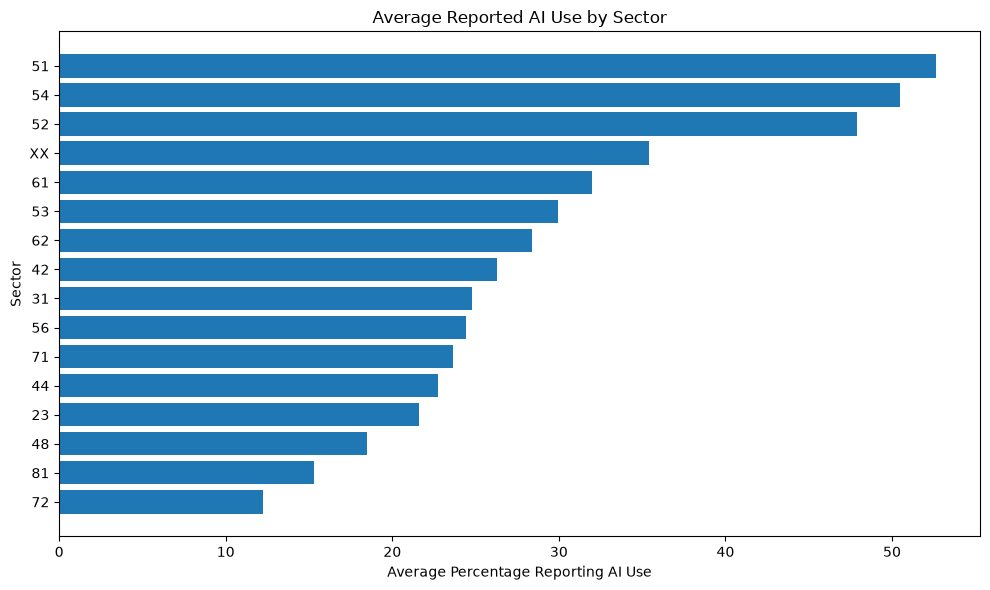

In [10]:
# Plot 3 — Average AI use by sector
ai_by_sector = (
    modeling_df
    .groupby("Sector", dropna=False)["Target_Yes"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(ai_by_sector.index.astype(str), ai_by_sector.values)
plt.title("Average Reported AI Use by Sector")
plt.xlabel("Average Percentage Reporting AI Use")
plt.ylabel("Sector")
plt.tight_layout()
plt.savefig("eda_ai_use_by_sector.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Prepare features and leakage-safe preprocessing

`Sector` and `Empsize` are categorical predictors. Numeric Census estimates are median-imputed and categorical values are most-frequent-imputed inside the pipeline. Because the pipeline is fit separately on each training fold, test-fold information is not used to determine imputation values or category encoding.

In [11]:
X = modeling_df.drop(columns=target_cols + ["Target_Total"]).copy()
Y = modeling_df[target_cols].copy()

# Normalize category types so sklearn does not encounter mixed int/string values
X["Sector"] = X["Sector"].astype(str)
X["Empsize"] = X["Empsize"].astype(str)

categorical_cols = ["Sector", "Empsize"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]),
            categorical_cols,
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_cols,
        ),
    ],
    remainder="drop",
)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Categorical predictors:", categorical_cols)
print("Numeric predictors:", len(numeric_cols))

X shape: (89, 40)
Y shape: (89, 3)
Categorical predictors: ['Sector', 'Empsize']
Numeric predictors: 38


## 9. Baseline and model comparison

Mean Absolute Error (MAE) is used because the targets are percentages and MAE is directly interpretable as the average absolute percentage-point error. Lower MAE is better.

All models are evaluated using the **same shuffled 5-fold cross-validation splits**. Predicted response shares are clipped at zero and normalized to sum to 100 before scoring.

In [12]:
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

model_specs = {
    "Baseline (Mean)": MultiOutputRegressor(DummyRegressor(strategy="mean")),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.03,
            max_depth=2,
            random_state=RANDOM_STATE,
        )
    ),
}


def normalize_predictions(pred):
    pred = np.asarray(pred, dtype=float)
    pred = np.clip(pred, 0, None)
    totals = pred.sum(axis=1, keepdims=True)
    totals[totals == 0] = 1.0
    return pred / totals * 100


def make_pipeline(estimator):
    return Pipeline([
        ("prep", clone(preprocessor)),
        ("model", clone(estimator)),
    ])

results = []
oof_predictions = {}

for model_name, estimator in model_specs.items():
    fold_mae = []
    oof_pred = np.zeros((len(X), len(target_cols)), dtype=float)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        Y_train, Y_test = Y.iloc[train_idx], Y.iloc[test_idx]

        pipeline = make_pipeline(estimator)
        pipeline.fit(X_train, Y_train)

        pred = normalize_predictions(pipeline.predict(X_test))
        oof_pred[test_idx] = pred
        fold_mae.append(mean_absolute_error(Y_test, pred))

    oof_predictions[model_name] = oof_pred

    results.append({
        "Model": model_name,
        "Mean_MAE": np.mean(fold_mae),
        "Std_MAE": np.std(fold_mae),
        **{f"Fold_{i+1}": v for i, v in enumerate(fold_mae)},
    })

comparison = (
    pd.DataFrame(results)
    .sort_values("Mean_MAE")
    .reset_index(drop=True)
)

display(comparison.round(4))

non_baseline = comparison[comparison["Model"] != "Baseline (Mean)"].copy()
best_model_name = non_baseline.iloc[0]["Model"]
best_cv_mae = non_baseline.iloc[0]["Mean_MAE"]
baseline_cv_mae = comparison.loc[
    comparison["Model"] == "Baseline (Mean)", "Mean_MAE"
].iloc[0]

print("Best trained model:", best_model_name)
print("Best CV MAE:", round(best_cv_mae, 4))
print("Baseline CV MAE:", round(baseline_cv_mae, 4))
print("Improvement vs baseline:", round(baseline_cv_mae - best_cv_mae, 4))

,Model,Mean_MAE,Std_MAE,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5
0,Gradient Boosting,4.9874,0.2182,5.2188,5.2653,4.9338,4.7419,4.7774
1,Random Forest,5.8309,0.6657,5.7714,6.0036,4.6297,6.6469,6.1029
2,Decision Tree,6.9205,0.6666,6.9923,7.7528,6.7337,7.3468,5.7771
3,Baseline (Mean),9.6287,1.1679,9.8670,8.3369,8.8637,9.3432,11.7329


Best trained model: Gradient Boosting
Best CV MAE: 4.9874
Baseline CV MAE: 9.6287
Improvement vs baseline: 4.6413


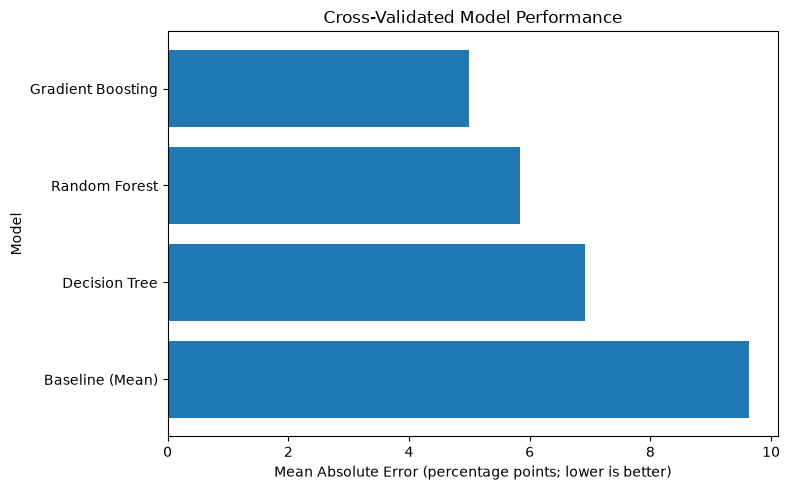

In [13]:
# Plot 4 — Cross-validated model comparison
plot_comparison = comparison.sort_values("Mean_MAE", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(plot_comparison["Model"], plot_comparison["Mean_MAE"])
plt.title("Cross-Validated Model Performance")
plt.xlabel("Mean Absolute Error (percentage points; lower is better)")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig("model_comparison_mae.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Final model and out-of-fold error analysis

The selected model is determined by cross-validated MAE. Error analysis below uses **out-of-fold predictions**, so each row is evaluated using a model that was not trained on that row.

In [14]:
best_estimator = model_specs[best_model_name]
best_oof_pred = oof_predictions[best_model_name]

per_target_mae = pd.DataFrame({
    "Target": ["Yes", "No", "Do not know"],
    "MAE": [
        mean_absolute_error(Y.iloc[:, i], best_oof_pred[:, i])
        for i in range(len(target_cols))
    ]
})

print("Cross-validated MAE by target:")
display(per_target_mae.round(4))

error_df = modeling_df[["Sector", "Empsize"] + target_cols].copy()
error_df[["Pred_Yes", "Pred_No", "Pred_Do_not_know"]] = best_oof_pred

for actual_col, pred_col, error_col in [
    ("Target_Yes", "Pred_Yes", "Error_Yes"),
    ("Target_No", "Pred_No", "Error_No"),
    ("Target_Do_not_know", "Pred_Do_not_know", "Error_Do_not_know"),
]:
    error_df[error_col] = (error_df[pred_col] - error_df[actual_col]).abs()

error_df["Row_MAE"] = error_df[
    ["Error_Yes", "Error_No", "Error_Do_not_know"]
].mean(axis=1)

print("Largest out-of-fold prediction errors:")
display(error_df.sort_values("Row_MAE", ascending=False).head(15).round(2))

Cross-validated MAE by target:


,Target,MAE
0,Yes,5.3638
1,No,6.2206
2,Do not know,3.3849


Largest out-of-fold prediction errors:


,Sector,Empsize,Target_Yes,Target_No,Target_Do_not_know,Pred_Yes,Pred_No,Pred_Do_not_know,Error_Yes,Error_No,Error_Do_not_know,Row_MAE
34,51,D,61.9,19.8,18.3,36.06,48.20,15.74,25.84,28.40,2.56,18.94
57,56,E,30.1,58.9,11.0,45.95,38.51,15.54,15.85,20.39,4.54,13.59
52,54,G,56.4,12.0,31.6,46.58,30.60,22.81,9.82,18.60,8.79,12.40
24,44,F,30.1,46.3,23.6,23.78,63.74,12.48,6.32,17.44,11.12,11.63
51,54,F,58.9,16.6,24.5,47.92,32.66,19.43,10.98,16.06,5.07,10.71
28,48,D,16.4,73.0,10.5,31.06,57.23,11.71,14.66,15.77,1.21,10.55
88,XX,G,46.0,27.9,26.1,36.38,43.49,20.13,9.62,15.59,5.97,10.39
17,42,E,38.6,52.5,8.9,23.71,61.46,14.83,14.89,8.96,5.93,9.93
38,52,D,33.8,45.8,20.3,48.60,31.98,19.42,14.80,13.82,0.88,9.83
10,31,E,27.3,55.2,17.5,41.10,46.57,12.33,13.80,8.63,5.17,9.20


## 11. Fit the selected model on all usable observations

This fitted model is used for feature interpretation and for generating the final model estimates. The cross-validated results above remain the appropriate measure of expected performance.

In [15]:
final_model = make_pipeline(best_estimator)
final_model.fit(X, Y)

final_pred = normalize_predictions(final_model.predict(X))

final_predictions = modeling_df[["Sector", "Empsize"] + target_cols].copy()
final_predictions[["Pred_Yes", "Pred_No", "Pred_Do_not_know"]] = final_pred
final_predictions["Pred_Total"] = final_predictions[
    ["Pred_Yes", "Pred_No", "Pred_Do_not_know"]
].sum(axis=1)

print("Final fitted model:", best_model_name)
print("Prediction totals close to 100:",
      np.allclose(final_predictions["Pred_Total"], 100.0))
display(final_predictions.head().round(2))

Final fitted model: Gradient Boosting
Prediction totals close to 100: True


,Sector,Empsize,Target_Yes,Target_No,Target_Do_not_know,Pred_Yes,Pred_No,Pred_Do_not_know,Pred_Total
0,23,A,13.4,79.8,6.8,14.61,77.29,8.10,100.0
1,23,B,13.8,79.2,7.0,18.19,73.65,8.16,100.0
2,23,C,23.2,67.2,9.6,20.50,70.21,9.29,100.0
3,23,D,21.7,69.3,9.0,25.00,64.10,10.89,100.0
4,23,E,24.3,63.9,11.8,26.07,62.08,11.85,100.0


## 12. Feature importance / model interpretation

For tree-based models, importance is averaged across the three output models when necessary. If a different estimator is selected, the notebook reports that built-in feature importance is not available through this method.

Top 15 features:


,Feature,Importance
0,"num__In the last two weeks, how did the prices...",0.18362
1,"num__In the last two weeks, how did this busin...",0.16580
2,"num__In the last six months, did this business...",0.14289
3,"num__In the last two weeks, how did this busin...",0.08791
4,"num__In the last two weeks, how did the time i...",0.07386
5,"num__In the last two weeks, how did this busin...",0.06813
6,"num__In the last two weeks, how did this busin...",0.05049
7,"num__In the last two weeks, how did the time i...",0.02819
8,"num__In the last two weeks, how did demand for...",0.01808
9,"num__In the last six months, in what ways did ...",0.01781


C:\Users\McCaiT01\AppData\Local\Temp\ipykernel_25848\1192685837.py:33: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


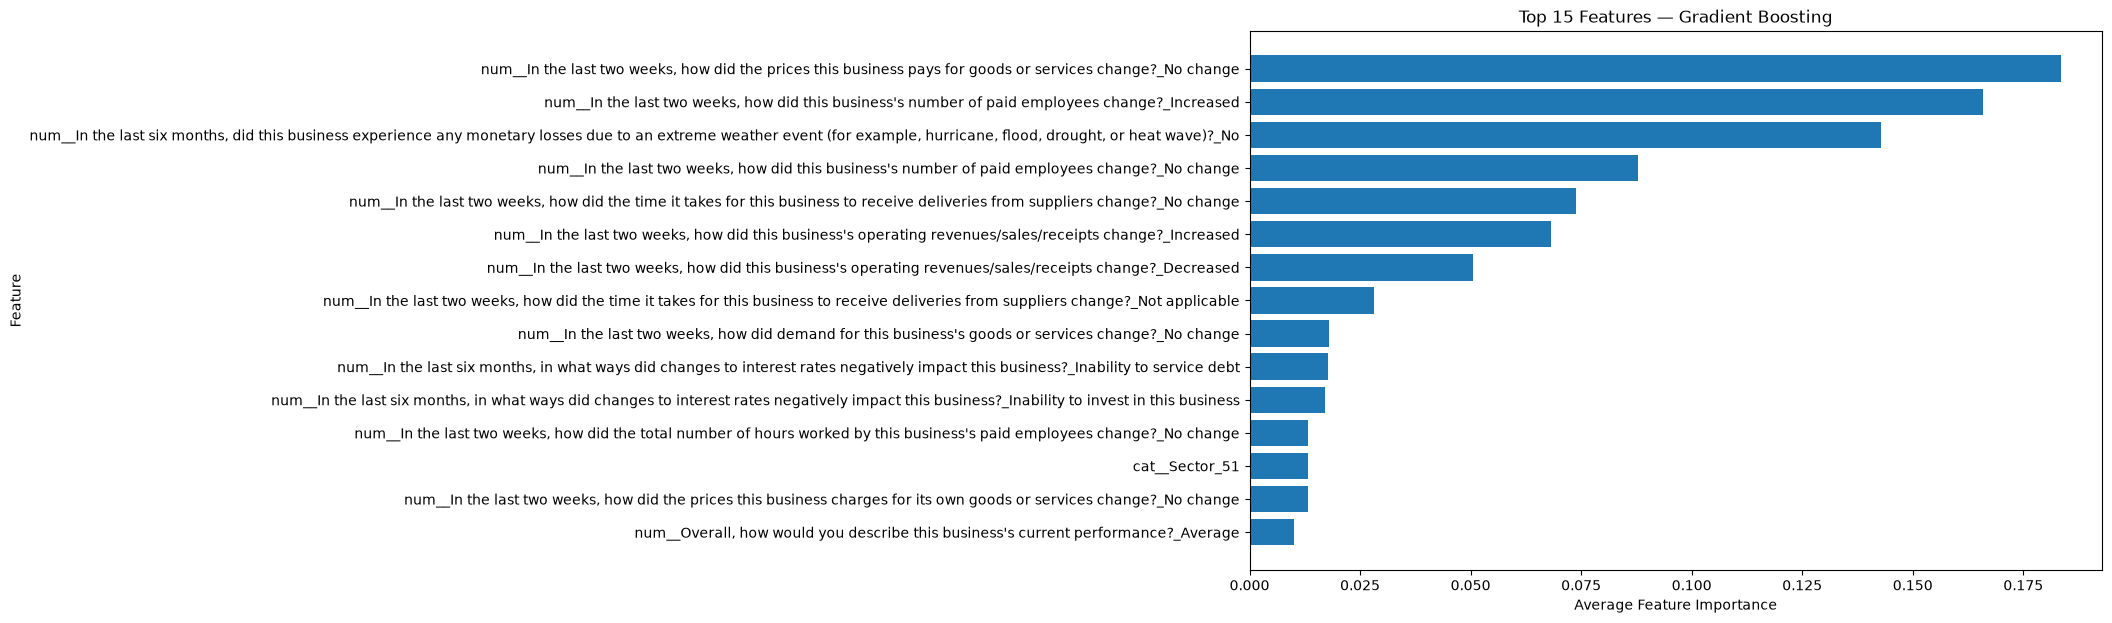

In [16]:
fitted_prep = final_model.named_steps["prep"]
fitted_model = final_model.named_steps["model"]
feature_names = fitted_prep.get_feature_names_out()

importance = None

if isinstance(fitted_model, MultiOutputRegressor):
    estimators = fitted_model.estimators_
    if all(hasattr(est, "feature_importances_") for est in estimators):
        importance = np.mean(
            [est.feature_importances_ for est in estimators],
            axis=0
        )
elif hasattr(fitted_model, "feature_importances_"):
    importance = fitted_model.feature_importances_

if importance is not None:
    feature_importance = (
        pd.DataFrame({"Feature": feature_names, "Importance": importance})
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    print("Top 15 features:")
    display(feature_importance.head(15).round(5))

    top_features = feature_importance.head(15).sort_values("Importance")
    plt.figure(figsize=(11, 7))
    plt.barh(top_features["Feature"], top_features["Importance"])
    plt.title(f"Top 15 Features — {best_model_name}")
    plt.xlabel("Average Feature Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    feature_importance = pd.DataFrame()
    print(f"Built-in feature importance is not available for {best_model_name}.")

## 13. Export results

Exports use relative filenames so the notebook is portable across computers. No user-specific Windows path is required.

In [17]:
comparison.to_csv("model_comparison.csv", index=False)
per_target_mae.to_csv("per_target_mae.csv", index=False)
error_df.to_csv("final_prediction_error_diagnostics.csv", index=False)
final_predictions.to_csv("final_AI_use_predictions.csv", index=False)
final_predictions.to_excel("final_AI_use_predictions.xlsx", index=False)

if not feature_importance.empty:
    feature_importance.to_csv("feature_importance.csv", index=False)

print("Created:")
print("- model_comparison.csv")
print("- per_target_mae.csv")
print("- final_prediction_error_diagnostics.csv")
print("- final_AI_use_predictions.csv")
print("- final_AI_use_predictions.xlsx")
if not feature_importance.empty:
    print("- feature_importance.csv")
print("- eda_target_distribution.png")
print("- eda_ai_use_by_employment_size.png")
print("- eda_ai_use_by_sector.png")
print("- model_comparison_mae.png")
print("- feature_importance.png (when available)")

Created:
- model_comparison.csv
- per_target_mae.csv
- final_prediction_error_diagnostics.csv
- final_AI_use_predictions.csv
- final_AI_use_predictions.xlsx
- feature_importance.csv
- eda_target_distribution.png
- eda_ai_use_by_employment_size.png
- eda_ai_use_by_sector.png
- model_comparison_mae.png
- feature_importance.png (when available)
